In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
adata_vis = sc.read_h5ad('../data/simulation_Mouse_Kidney_MERFISH/MK_simulated_ST.h5ad')
pred_df = pd.read_csv('./mydestvi_predicted_proportions_mmdAndL1.csv')

In [3]:
# 都转成字符串类型
pred_df.index = pred_df.index.astype(str)

发现 'true_proportion'，开始计算与预测值的相关性。

预测丰度与真实丰度的皮尔逊相关系数 (按细胞类型):
kidney collecting duct epithelial cell             0.836627
kidney distal convoluted tubule epithelial cell    0.906198
kidney loop of Henle epithelial cell               0.964109
pericyte                                           0.917886
immune cell                                        0.219122
epithelial cell of proximal tubule                 0.969881
endothelial cell                                   0.791503
podocyte                                           0.927722
dtype: float64

平均相关系数:  0.816631059196887
相关性柱状图已保存为 'destvi_validation_correlation.png'


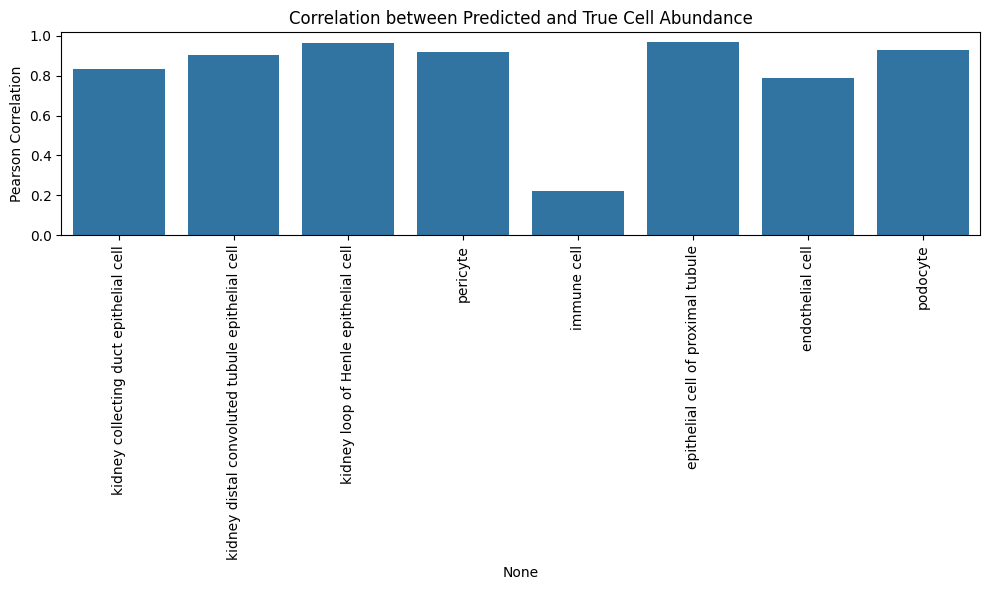

In [4]:
# 可选验证：与 true_proportion 的相关性
if 'true_proportion' in adata_vis.obsm:
    print("发现 'true_proportion'，开始计算与预测值的相关性。")
    true_df = pd.DataFrame(adata_vis.obsm['true_proportion'],
                           index=adata_vis.obs_names,
                           columns=adata_vis.uns['cell_types'])
    common_cell_types = list(set(pred_df.columns) & set(true_df.columns))
    if not common_cell_types:
        print("警告：预测的细胞类型和真实的细胞类型没有交集，无法进行相关性比较！")
    else:
        pred_c = pred_df[common_cell_types]
        true_c = true_df[common_cell_types]
        correlations = pred_c.corrwith(true_c, axis=0)
        print("\n预测丰度与真实丰度的皮尔逊相关系数 (按细胞类型):")
        print(correlations)
        print("\n平均相关系数: ", correlations.mean())
        plt.figure(figsize=(10, 6))
        sns.barplot(x=correlations.index, y=correlations.values)
        plt.xticks(rotation=90)
        plt.ylabel("Pearson Correlation")
        plt.title("Correlation between Predicted and True Cell Abundance")
        plt.tight_layout()
        plt.savefig("destvi_validation_correlation.png", dpi=300)
        print("相关性柱状图已保存为 'destvi_validation_correlation.png'")
else:
    print("在空间数据中未找到 'true_proportion'，跳过验证步骤。")


In [5]:
    # 计算每个Spot的RMSE
import numpy as np
rmse_per_spot = np.sqrt(((pred_c - true_c) ** 2).mean(axis=1))
print("\n每个Spot的RMSE：")
print(rmse_per_spot)
print("均方根误差均值：", np.mean(rmse_per_spot))


每个Spot的RMSE：
0       0.064563
1       0.051499
2       0.042235
3       0.061581
4       0.053867
          ...   
1515    0.036610
1516    0.004306
1517    0.031837
1518    0.029430
1519    0.158775
Length: 1520, dtype: float64
均方根误差均值： 0.06760247451726557


In [6]:
from scipy.spatial.distance import jensenshannon

# 归一化，确保每个spot的比例和为1
pred_norm = pred_c.div(pred_c.sum(axis=1), axis=0)
true_norm = true_c.div(true_c.sum(axis=1), axis=0)

jsd_list = []
for i in range(pred_norm.shape[0]):
    p = pred_norm.iloc[i].values
    q = true_norm.iloc[i].values
    jsd = jensenshannon(p, q, base=2)  # base=2得到0~1之间的JSD
    jsd_list.append(jsd)

jsd_per_spot = pd.Series(jsd_list, index=pred_norm.index)
print("\n每个Spot的JSD：")
print(jsd_per_spot)
print("JSD均值：", jsd_per_spot.mean())



每个Spot的JSD：
0       0.262675
1       0.290959
2       0.182751
3       0.250257
4       0.198046
          ...   
1515    0.131260
1516    0.069281
1517    0.190682
1518    0.175422
1519    0.460702
Length: 1520, dtype: float64
JSD均值： 0.26876924854181483
